# Calibration: fitting vulnerability to observed losses

This notebook walks through `natcat.calibration`: load an observed US-landfall loss
table, precompute one wind footprint per storm on its regional LitPop exposure, fit
`ValueDependentVulnerability`'s parameters against those losses, and apply the
calibrated model to Hurricane Michael (2018). See
[Calibration](../docs/user-guide/calibration.md) and
[Calibration methodology](../docs/methodology/calibration.md) for the full write-up,
in particular the caveats around the bundled loss data before reading much into the
numbers below.


In [1]:
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from natcat import plotting

plotting.apply_style()
pd.options.display.float_format = "{:,.2f}".format


NumExpr defaulting to 10 threads.


## Observed losses

`load_observed_losses` reads the bundled NHC US-landfall table (total damage estimate
per storm from the NHC Tropical Cyclone Report, nominal USD of the loss year).
`normalise_losses` brings every storm to the price level of the exposure's reference
year (2018, LitPop's default) via CPI normalisation, and adds `observed_loss_ref_usd`
&#8212; the calibration target.


In [2]:
from natcat.calibration import load_observed_losses, normalise_losses

observed = normalise_losses(load_observed_losses(), reference_year=2018)
print(f"{len(observed)} storms in the calibration set (surge/flood-dominated storms excluded)")
observed[["storm_id", "name", "year", "damage_driver", "observed_loss_usd", "observed_loss_ref_usd"]]


19 storms in the calibration set (surge/flood-dominated storms excluded)


,storm_id,name,year,damage_driver,observed_loss_usd,observed_loss_ref_usd
0,AL111989,Hugo,1989,mixed,"7,000,000,000.00","14,175,000,000.00"
1,AL041992,Andrew,1992,wind,"26,500,000,000.00","47,428,011,404.13"
2,AL171995,Opal,1995,mixed,"3,000,000,000.00","4,942,913,385.83"
3,AL061996,Fran,1996,mixed,"3,200,000,000.00","5,121,223,709.37"
4,AL032004,Charley,2004,wind,"15,000,000,000.00","19,939,121,228.16"
5,AL062004,Frances,2004,mixed,"9,000,000,000.00","11,963,472,736.90"
6,AL092004,Ivan,2004,mixed,"14,200,000,000.00","18,875,701,429.33"
7,AL112004,Jeanne,2004,wind,"6,900,000,000.00","9,171,995,764.96"
8,AL042005,Dennis,2005,mixed,"2,230,000,000.00","2,867,142,857.14"
9,AL252005,Wilma,2005,wind,"20,600,000,000.00","26,485,714,285.71"


## Cases

A storm's wind footprint does not depend on the vulnerability parameters, so it is
computed once per storm and cached &#8212; `build_cases` downloads each best track,
derives an exposure box around its landfall, loads the regional LitPop exposure, and
evaluates the footprint. Re-evaluating the loss for a new parameter set is then a
single vectorised pass, which is what makes the optimiser fast. We reuse a cached set
if one exists from a previous run of this notebook or `scripts/calibrate.py`.


In [3]:
from pathlib import Path

from natcat.calibration import build_cases, load_cases, save_cases

cases_path = Path("..") / ".cache" / "calibration_cases.pkl"
if cases_path.exists():
    cases = load_cases(cases_path)
    print(f"Loaded {len(cases)} cached cases from {cases_path}")
else:
    cases = build_cases(observed)
    save_cases(cases, cases_path)
    print(f"Built and cached {len(cases)} cases to {cases_path}")


Loaded 19 cached cases from ../.cache/calibration_cases.pkl


## Baseline: before calibration

`ValueDependentVulnerability()` with its defaults (`v50_slope=0`) is exactly a single
`WindVulnerability` curve. How far off is it from the observed losses before any
fitting?


In [4]:
from natcat.calibration import Calibrator
from natcat.vulnerability import ValueDependentVulnerability

calibrator = Calibrator(cases, ValueDependentVulnerability())

baseline = pd.DataFrame(
    {
        "storm": [c.name for c in cases],
        "observed": calibrator.observed,
        "modelled (uncalibrated)": calibrator.modelled_losses(),
    }
)
baseline["ratio"] = baseline["modelled (uncalibrated)"] / baseline["observed"]
baseline


,storm,observed,modelled (uncalibrated),ratio
0,Hugo,"14,175,000,000.00","127,244,849,570.24",8.98
1,Andrew,"47,428,011,404.13","489,330,395,775.49",10.32
2,Opal,"4,942,913,385.83","29,231,752,282.31",5.91
3,Fran,"5,121,223,709.37","35,367,422,993.87",6.91
4,Charley,"19,939,121,228.16","378,077,555,968.64",18.96
5,Frances,"11,963,472,736.90","73,405,235,686.26",6.14
6,Ivan,"18,875,701,429.33","49,324,062,117.14",2.61
7,Jeanne,"9,171,995,764.96","126,608,888,818.15",13.80
8,Dennis,"2,867,142,857.14","31,215,619,945.27",10.89
9,Wilma,"26,485,714,285.71","456,698,040,662.06",17.24


## Fit

`method="global"` runs differential evolution over the model's default parameter
bounds, followed by a local Nelder-Mead polish. 100 iterations is enough for a
reasonable fit and keeps this notebook's runtime short; `scripts/calibrate.py` uses
200 by default for the documentation figures.


In [5]:
result = calibrator.fit(method="global", maxiter=100, seed=0)
print(result.summary())


Calibration (global, 7735 evaluations): Maximum number of iterations has been exceeded.; polished
    threshold_kt:        40 ->     34.01
         v50_ref:       105 ->     90.04
       v50_slope:         0 ->        30
               k:      0.12 ->   0.05001
           scale:         1 ->         1
  objective     : 0.6855 -> 0.1640 (typical factor error 6.73x -> 2.54x)


In [6]:
result.table


,storm_id,name,observed,modelled_initial,modelled,log_ratio_initial,log_ratio,weight
0,AL111989,Hugo,"14,175,000,000.00","127,244,849,570.24","24,351,959,910.91",0.95,0.24,1.00
1,AL041992,Andrew,"47,428,011,404.13","489,330,395,775.49","73,300,482,738.82",1.01,0.19,1.00
2,AL171995,Opal,"4,942,913,385.83","29,231,752,282.31","8,189,831,036.65",0.77,0.22,1.00
3,AL061996,Fran,"5,121,223,709.37","35,367,422,993.87","15,999,287,814.58",0.84,0.49,1.00
4,AL032004,Charley,"19,939,121,228.16","378,077,555,968.64","84,722,470,840.00",1.28,0.63,1.00
5,AL062004,Frances,"11,963,472,736.90","73,405,235,686.26","13,103,632,800.53",0.79,0.04,1.00
6,AL092004,Ivan,"18,875,701,429.33","49,324,062,117.14","12,273,001,028.15",0.42,-0.19,1.00
7,AL112004,Jeanne,"9,171,995,764.96","126,608,888,818.15","27,283,174,546.50",1.14,0.47,1.00
8,AL042005,Dennis,"2,867,142,857.14","31,215,619,945.27","6,400,661,571.15",1.04,0.35,1.00
9,AL252005,Wilma,"26,485,714,285.71","456,698,040,662.06","33,200,171,294.53",1.24,0.10,1.00


## Plots


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)


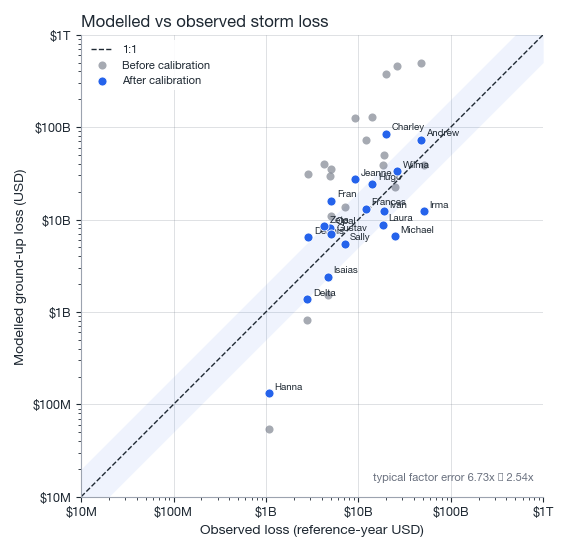

In [7]:
fig, ax = plotting.plot_calibration(result, title="Modelled vs observed storm loss")


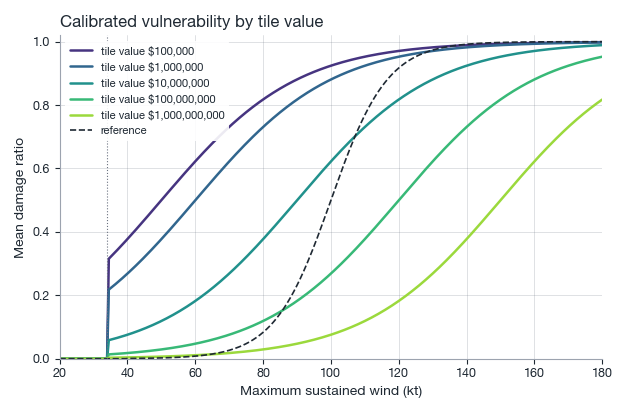

In [8]:
from natcat.vulnerability import WindVulnerability

fig, ax = plotting.plot_value_dependent_curves(
    result.model,
    reference=WindVulnerability("Frame"),
    title="Calibrated vulnerability by tile value",
)


## Applying the calibrated model to Hurricane Michael

`result.model` is a plain `VulnerabilityModel`, so it drops straight into
`LossCalculator` in place of `WindVulnerability`. We compare both on the same
Hurricane Michael (2018) footprint and LitPop portfolio used in the single-event
notebook.


In [9]:
from natcat.exposure import load_litpop_exposure
from natcat.hazards import TropicalCycloneHazard
from natcat.loss import LossCalculator
from natcat.tracks import load_best_track

track = load_best_track(2018, "al", "14")
portfolio = load_litpop_exposure("USA", bounds=(24.5, 32.0, -87.6, -80.0))
hazard = TropicalCycloneHazard(track)

loss_uncalibrated = LossCalculator(hazard, WindVulnerability()).compute(portfolio)["loss"].sum()
loss_calibrated = LossCalculator(hazard, result.model).compute(portfolio)["loss"].sum()

print(f"WindVulnerability():  ${loss_uncalibrated:,.0f}")
print(f"result.model:         ${loss_calibrated:,.0f}")
print(f"NHC TCR estimate (reference-year USD): ${observed.loc[observed['name'] == 'Michael', 'observed_loss_ref_usd'].iloc[0]:,.0f}")


Fetching LitPop exposure for USA via the CLIMADA data API.


WindVulnerability():  $15,966,925,090
result.model:         $6,618,617,117
NHC TCR estimate (reference-year USD): $25,000,000,000


## Caveats

This calibration is fit to about 19 storms' total NHC-reported damage, CPI-normalised
but not adjusted for exposure growth, against a wind-only model and LitPop's proxy
asset values &#8212; not an insured, wind-only loss dataset. See
[Calibration methodology &#8212; Caveats](../docs/methodology/calibration.md#caveats)
before using `result.model` (or the bundled loss table) for anything beyond exploring
how the pipeline responds to a different vulnerability curve.
